In [ ]:
!pip install -q pandas matplotlib numpy nrclex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.3 MB/s eta 0:00:00


In [ ]:
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from nrclex import NRCLex

In [ ]:
CSV_PATH = "/content/Sexual Violence sampled data - Final_Stigma_and_Support.csv"

stigma_df = pd.read_csv(CSV_PATH)

print("Shape:", stigma_df.shape)
print("Columns:")
print(stigma_df.columns.tolist())
display(stigma_df.head())

Shape: (4631, 16)
Columns:
['post_id', 'subreddit', 'post_title', 'post_url', 'post_body', 'comment_id', 'author', 'comment_body', 'created_utc', 'score', 'permalink', 'depth', 'timestamp', 'support_tags', 'body_y', 'stigma_tags']


,post_id,subreddit,post_title,post_url,post_body,comment_id,author,comment_body,created_utc,score,permalink,depth,timestamp,support_tags,body_y,stigma_tags
0,om798f,SexualHarassment,I'm not sure if I was sexually harassed or abu...,https://www.reddit.com/r/SexualHarassment/comm...,I (f23) was friends with a guy with whom I had...,h5j5kk8,gacGGE,I wouldn't forgive him but I'm not you. He say...,1626540383,2,https://www.reddit.com/r/SexualHarassment/comm...,1,2021-07-17 16:46:23,"Information Support, Esteem Support",I (f23) was friends with a guy with whom I had...,"Experienced, Internalized"
1,ol3l81,SexualHarassment,[deleted by user],https://www.reddit.com/r/SexualHarassment/comm...,I don’t know if this is workplace sexual haras...,h5bz1on,gacGGE,If it was an ex boyfriend it would be classifi...,1626389826,1,https://www.reddit.com/r/SexualHarassment/comm...,1,2021-07-15 22:57:06,Information Support,I don’t know if this is workplace sexual haras...,"Experienced, Internalized, Anticipated, Struct..."
2,ojmgbg,SexualHarassment,Serious help for a friend,https://www.reddit.com/r/SexualHarassment/comm...,What can my friend do about being sexually har...,h52l5q5,queenrothko,Hey. That is illegal and you should inform the...,1626204661,1,https://www.reddit.com/r/SexualHarassment/comm...,1,2021-07-13 19:31:01,"Information Support, Emotional Support",What can my friend do about being sexually har...,Experienced
3,ojmgbg,SexualHarassment,Serious help for a friend,https://www.reddit.com/r/SexualHarassment/comm...,What can my friend do about being sexually har...,h5314q6,queenrothko,If your friend needs free legal advice and sup...,1626211900,1,https://www.reddit.com/r/SexualHarassment/comm...,1,2021-07-13 21:31:40,"Information Support, Tangible Assistance",What can my friend do about being sexually har...,Experienced
4,ojkjeq,SexualHarassment,Am I in the wrong?,https://www.reddit.com/r/SexualHarassment/comm...,I had a good conversation with a guy that I ju...,h52fift,Familiar-Soft7902,"No, from the sound of it, you gave him exactly...",1626202162,2,https://www.reddit.com/r/SexualHarassment/comm...,1,2021-07-13 18:49:22,"Information Support, Esteem Support",I had a good conversation with a guy that I ju...,Internalized


In [ ]:
CSV_PATH = "/content/no_stigma_support_predictions.csv"

nonstigma_df = pd.read_csv(CSV_PATH)

print("Shape:", nonstigma_df.shape)
print("Columns:")
print(nonstigma_df.columns.tolist())
display(nonstigma_df.head())

Shape: (1175, 13)
Columns:
['body', 'l2_json', 'l2_label', 'l2_reason', 'l2_evidence', 'post_id', 'comment_id', 'comment_author', 'comment_text', 'comment_score', 'comment_created_utc', 'support_json', 'support_labels']


,body,l2_json,l2_label,l2_reason,l2_evidence,post_id,comment_id,comment_author,comment_text,comment_score,comment_created_utc,support_json,support_labels
0,"So, to make a long story short, my mom will gr...","{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes potential sexual harassment...,NaN,ojp7lk,h539sfg,queenrothko,You’re not being dramatic at all. You’ve told ...,4,1626216078,"{""label_presence"": {""Information Support"": tru...","Information Support, Emotional Support, Esteem..."
1,"So, to make a long story short, my mom will gr...","{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes potential sexual harassment...,NaN,ojp7lk,h54ufu8,indyradmama,More like sexual assault!! you have every rig...,5,1626252279,"{""label_presence"": {""Information Support"": tru...","Information Support, Emotional Support, Esteem..."
2,"So, to make a long story short, my mom will gr...","{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes potential sexual harassment...,NaN,ojp7lk,h54zdn2,[deleted],"If she tries doing this again, attack her or f...",1,1626256899,"{""label_presence"": {""Information Support"": tru...","Information Support, Emotional Support, Esteem..."
3,Earlier today at school I experienced unwanted...,"{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes an experience of unwanted t...,NaN,o79e7h,h2xdoq5,Acceptable_Copy933,It’s okay to dm me,4,1624567183,"{""label_presence"": {""Information Support"": fal...",Tangible Assistance
4,Earlier today at school I experienced unwanted...,"{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes an experience of unwanted t...,NaN,o79e7h,h2xd7ht,[deleted],[deleted],3,1624566955,"{""label_presence"": {""Information Support"": fal...",NaN


# Prepare stigma (post-level) and support (comment-level)

In [ ]:
# ----------------------------
# STIGMA POSTS
# ----------------------------
stigma_post_df = stigma_df[
    ["post_id", "post_body", "stigma_tags"]
].copy()

stigma_post_df = stigma_post_df.dropna(subset=["post_body"]).copy()
stigma_post_df["text"] = stigma_post_df["post_body"].fillna("").astype(str).str.strip()

# ----------------------------
# STIGMA SUPPORT
# ----------------------------
stigma_support_df = stigma_df[
    ["post_id", "comment_id", "comment_body", "stigma_tags"]
].copy()

stigma_support_df = stigma_support_df.dropna(subset=["comment_body"]).copy()
stigma_support_df["text"] = stigma_support_df["comment_body"].fillna("").astype(str).str.strip()

# ----------------------------
# NON-STIGMA POSTS
# ----------------------------
nonstigma_post_df = nonstigma_df[
    ["post_id", "body"]
].copy()

nonstigma_post_df = nonstigma_post_df.dropna(subset=["body"]).copy()
nonstigma_post_df["text"] = nonstigma_post_df["body"].fillna("").astype(str).str.strip()

# ----------------------------
# NON-STIGMA SUPPORT
# ----------------------------
nonstigma_support_df = nonstigma_df[
    ["post_id", "comment_id", "comment_text"]
].copy()

nonstigma_support_df = nonstigma_support_df.dropna(subset=["comment_text"]).copy()
nonstigma_support_df["text"] = nonstigma_support_df["comment_text"].fillna("").astype(str).str.strip()

print("Stigma posts:", stigma_post_df.shape)
print("Stigma support:", stigma_support_df.shape)
print("Non-stigma posts:", nonstigma_post_df.shape)
print("Non-stigma support:", nonstigma_support_df.shape)

Stigma posts: (4631, 4)
Stigma support: (4631, 5)
Non-stigma posts: (1175, 3)
Non-stigma support: (1175, 4)


In [ ]:
def clean_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"&amp;|amp", " ", x)
    x = re.sub(r">+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

stigma_post_df["clean_text"] = stigma_post_df["text"].apply(clean_text)
stigma_support_df["clean_text"] = stigma_support_df["text"].apply(clean_text)

nonstigma_post_df["clean_text"] = nonstigma_post_df["text"].apply(clean_text)
nonstigma_support_df["clean_text"] = nonstigma_support_df["text"].apply(clean_text)

stigma_post_df = stigma_post_df[stigma_post_df["clean_text"].str.strip() != ""].copy()
stigma_support_df = stigma_support_df[stigma_support_df["clean_text"].str.strip() != ""].copy()

nonstigma_post_df = nonstigma_post_df[nonstigma_post_df["clean_text"].str.strip() != ""].copy()
nonstigma_support_df = nonstigma_support_df[nonstigma_support_df["clean_text"].str.strip() != ""].copy()

print("After cleaning:")
print("stigma posts:", stigma_post_df.shape)
print("stigma support:", stigma_support_df.shape)
print("non-stigma posts:", nonstigma_post_df.shape)
print("non-stigma support:", nonstigma_support_df.shape)

After cleaning:
stigma posts: (4631, 5)
stigma support: (4630, 6)
non-stigma posts: (1175, 4)
non-stigma support: (1174, 5)


In [ ]:
bot_patterns = [
    "if you or someone you know is contemplating suicide",
    "please reach out to",
    "reddit help resources",
    "this post has been removed",
    "contact the moderators",
    "subreddit rules",
    "performed automatically",
    "i am a bot",
    "was performed automatically"
]

bot_regex = "|".join(bot_patterns)

stigma_support_df = stigma_support_df[
    ~stigma_support_df["clean_text"].str.contains(bot_regex, case=False, na=False)
].copy()

nonstigma_support_df = nonstigma_support_df[
    ~nonstigma_support_df["clean_text"].str.contains(bot_regex, case=False, na=False)
].copy()

print("Stigma support after bot/mod filtering:", stigma_support_df.shape)
print("Non-stigma support after bot/mod filtering:", nonstigma_support_df.shape)

Stigma support after bot/mod filtering: (4466, 6)
Non-stigma support after bot/mod filtering: (1147, 5)


In [ ]:
display(stigma_post_df.head())
display(stigma_support_df.head())
display(nonstigma_post_df.head())
display(nonstigma_support_df.head())

,post_id,post_body,stigma_tags,text,clean_text
0,om798f,I (f23) was friends with a guy with whom I had...,"Experienced, Internalized",I (f23) was friends with a guy with whom I had...,i (f23) was friends with a guy with whom i had...
1,ol3l81,I don’t know if this is workplace sexual haras...,"Experienced, Internalized, Anticipated, Struct...",I don’t know if this is workplace sexual haras...,i don’t know if this is workplace sexual haras...
2,ojmgbg,What can my friend do about being sexually har...,Experienced,What can my friend do about being sexually har...,what can my friend do about being sexually har...
3,ojmgbg,What can my friend do about being sexually har...,Experienced,What can my friend do about being sexually har...,what can my friend do about being sexually har...
4,ojkjeq,I had a good conversation with a guy that I ju...,Internalized,I had a good conversation with a guy that I ju...,i had a good conversation with a guy that i ju...


,post_id,comment_id,comment_body,stigma_tags,text,clean_text
0,om798f,h5j5kk8,I wouldn't forgive him but I'm not you. He say...,"Experienced, Internalized",I wouldn't forgive him but I'm not you. He say...,i wouldn't forgive him but i'm not you. he say...
1,ol3l81,h5bz1on,If it was an ex boyfriend it would be classifi...,"Experienced, Internalized, Anticipated, Struct...",If it was an ex boyfriend it would be classifi...,if it was an ex boyfriend it would be classifi...
2,ojmgbg,h52l5q5,Hey. That is illegal and you should inform the...,Experienced,Hey. That is illegal and you should inform the...,hey. that is illegal and you should inform the...
3,ojmgbg,h5314q6,If your friend needs free legal advice and sup...,Experienced,If your friend needs free legal advice and sup...,if your friend needs free legal advice and sup...
4,ojkjeq,h52fift,"No, from the sound of it, you gave him exactly...",Internalized,"No, from the sound of it, you gave him exactly...","no, from the sound of it, you gave him exactly..."


,post_id,body,text,clean_text
0,ojp7lk,"So, to make a long story short, my mom will gr...","So, to make a long story short, my mom will gr...","so, to make a long story short, my mom will gr..."
1,ojp7lk,"So, to make a long story short, my mom will gr...","So, to make a long story short, my mom will gr...","so, to make a long story short, my mom will gr..."
2,ojp7lk,"So, to make a long story short, my mom will gr...","So, to make a long story short, my mom will gr...","so, to make a long story short, my mom will gr..."
3,o79e7h,Earlier today at school I experienced unwanted...,Earlier today at school I experienced unwanted...,earlier today at school i experienced unwanted...
4,o79e7h,Earlier today at school I experienced unwanted...,Earlier today at school I experienced unwanted...,earlier today at school i experienced unwanted...


,post_id,comment_id,comment_text,text,clean_text
0,ojp7lk,h539sfg,You’re not being dramatic at all. You’ve told ...,You’re not being dramatic at all. You’ve told ...,you’re not being dramatic at all. you’ve told ...
1,ojp7lk,h54ufu8,More like sexual assault!! you have every rig...,More like sexual assault!! you have every rig...,more like sexual assault!! you have every righ...
2,ojp7lk,h54zdn2,"If she tries doing this again, attack her or f...","If she tries doing this again, attack her or f...","if she tries doing this again, attack her or f..."
3,o79e7h,h2xdoq5,It’s okay to dm me,It’s okay to dm me,it’s okay to dm me
4,o79e7h,h2xd7ht,[deleted],[deleted],[deleted]


In [ ]:
def parse_tag_list(x):
    if pd.isna(x):
        return []

    x = str(x).strip()
    if x == "":
        return []

    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return [str(v).strip() for v in val if str(v).strip()]
    except Exception:
        pass

    parts = re.split(r"[;,]", x)
    return [p.strip() for p in parts if p.strip()]

IEA_TAGS = {"Internalized", "Experienced", "Anticipated"}
STRUCTURAL_TAGS = {"Structural"}

def map_stigma_bucket(tag_str):
    tags = set(parse_tag_list(tag_str))

    if tags & STRUCTURAL_TAGS:
        return "Structural"
    elif tags & IEA_TAGS:
        return "Internalized/Experienced/Anticipated"
    else:
        return None

# assign grouped labels
stigma_post_df["stigma_group"] = stigma_post_df["stigma_tags"].apply(map_stigma_bucket)
stigma_support_df["stigma_group"] = stigma_support_df["stigma_tags"].apply(map_stigma_bucket)

nonstigma_post_df["stigma_group"] = "Non-stigma"
nonstigma_support_df["stigma_group"] = "Non-stigma"

print(stigma_post_df["stigma_group"].value_counts(dropna=False))
print(stigma_support_df["stigma_group"].value_counts(dropna=False))

stigma_group
Internalized/Experienced/Anticipated    3777
Structural                               608
None                                     246
Name: count, dtype: int64
stigma_group
Internalized/Experienced/Anticipated    3655
Structural                               572
None                                     239
Name: count, dtype: int64


In [ ]:
import pandas as pd

NRC_PATH = "/content/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"

nrc = pd.read_csv(
    NRC_PATH,
    sep="\t",
    names=["word", "emotion", "association"]
)

nrc.head()

,word,emotion,association
0,aback,anger,0
1,aback,anticipation,0
2,aback,disgust,0
3,aback,fear,0
4,aback,joy,0


In [ ]:
nrc = nrc[nrc["association"] == 1].copy()

In [ ]:
EMOTIONS = [
    "anger",
    "fear",
    "anticipation",
    "trust",
    "surprise",
    "sadness",
    "joy",
    "disgust"
]

nrc = nrc[nrc["emotion"].isin(EMOTIONS)]

In [ ]:
emotion_dict = defaultdict(list)

for _, row in nrc.iterrows():
    emotion_dict[row["word"]].append(row["emotion"])

print("Number of lexicon words:", len(emotion_dict))
print("Example:", dict(list(emotion_dict.items())[:5]))

Number of lexicon words: 4454
Example: {'abacus': ['trust'], 'abandon': ['fear', 'sadness'], 'abandoned': ['anger', 'fear', 'sadness'], 'abandonment': ['anger', 'fear', 'sadness', 'surprise'], 'abbot': ['trust']}


In [ ]:
def tokenize(text):
    text = str(text).lower()
    return re.findall(r"\b[a-z]+\b", text)

def get_nrc_emotion_counts(texts):
    counts = Counter()

    for text in texts:
        words = tokenize(text)
        for w in words:
            if w in emotion_dict:
                counts.update(emotion_dict[w])

    return {e: counts[e] for e in EMOTIONS}

def normalize_emotion_counts(emotion_dict_in):
    total = sum(emotion_dict_in.values())
    if total == 0:
        return {k: 0 for k in emotion_dict_in}
    return {k: v / total for k, v in emotion_dict_in.items()}

def compute_nrc_emotions(texts):
    raw = get_nrc_emotion_counts(texts)
    norm = normalize_emotion_counts(raw)
    return norm

In [ ]:
# ----------------------------
# DEDUPLICATE POSTS
# ----------------------------
stigma_post_unique = stigma_post_df.drop_duplicates(subset=["post_id"]).copy()
nonstigma_post_unique = nonstigma_post_df.drop_duplicates(subset=["post_id"]).copy()

# ----------------------------
# TEXT LISTS - POSTS
# ----------------------------
iea_post_texts = stigma_post_unique.loc[
    stigma_post_unique["stigma_group"] == "Internalized/Experienced/Anticipated",
    "clean_text"
].tolist()

structural_post_texts = stigma_post_unique.loc[
    stigma_post_unique["stigma_group"] == "Structural",
    "clean_text"
].tolist()

nonstigma_post_texts = nonstigma_post_unique["clean_text"].tolist()

# ----------------------------
# TEXT LISTS - SUPPORT
# ----------------------------
iea_support_texts = stigma_support_df.loc[
    stigma_support_df["stigma_group"] == "Internalized/Experienced/Anticipated",
    "clean_text"
].tolist()

structural_support_texts = stigma_support_df.loc[
    stigma_support_df["stigma_group"] == "Structural",
    "clean_text"
].tolist()

nonstigma_support_texts = nonstigma_support_df["clean_text"].tolist()

# ----------------------------
# NRC EMOTION SCORES
# ----------------------------
iea_post_emotions = compute_nrc_emotions(iea_post_texts)
structural_post_emotions = compute_nrc_emotions(structural_post_texts)
nonstigma_post_emotions = compute_nrc_emotions(nonstigma_post_texts)

iea_support_emotions = compute_nrc_emotions(iea_support_texts)
structural_support_emotions = compute_nrc_emotions(structural_support_texts)
nonstigma_support_emotions = compute_nrc_emotions(nonstigma_support_texts)

# ----------------------------
# DATAFRAMES
# ----------------------------
post_emotion_df = pd.DataFrame({
    "emotion": EMOTIONS,
    "internalized_experienced_anticipated": [iea_post_emotions[e] for e in EMOTIONS],
    "structural": [structural_post_emotions[e] for e in EMOTIONS],
    "non_stigma": [nonstigma_post_emotions[e] for e in EMOTIONS]
})

support_emotion_df = pd.DataFrame({
    "emotion": EMOTIONS,
    "internalized_experienced_anticipated": [iea_support_emotions[e] for e in EMOTIONS],
    "structural": [structural_support_emotions[e] for e in EMOTIONS],
    "non_stigma": [nonstigma_support_emotions[e] for e in EMOTIONS]
})

display(post_emotion_df.round(3))
display(support_emotion_df.round(3))

,emotion,internalized_experienced_anticipated,structural,non_stigma
0,anger,0.120,0.122,0.113
1,fear,0.135,0.153,0.132
2,anticipation,0.154,0.138,0.165
3,trust,0.194,0.208,0.217
4,surprise,0.057,0.058,0.057
5,sadness,0.137,0.134,0.115
6,joy,0.113,0.102,0.128
7,disgust,0.090,0.084,0.073


,emotion,internalized_experienced_anticipated,structural,non_stigma
0,anger,0.131,0.131,0.125
1,fear,0.143,0.156,0.146
2,anticipation,0.135,0.128,0.142
3,trust,0.217,0.229,0.223
4,surprise,0.054,0.054,0.056
5,sadness,0.122,0.121,0.112
6,joy,0.117,0.101,0.123
7,disgust,0.081,0.079,0.072


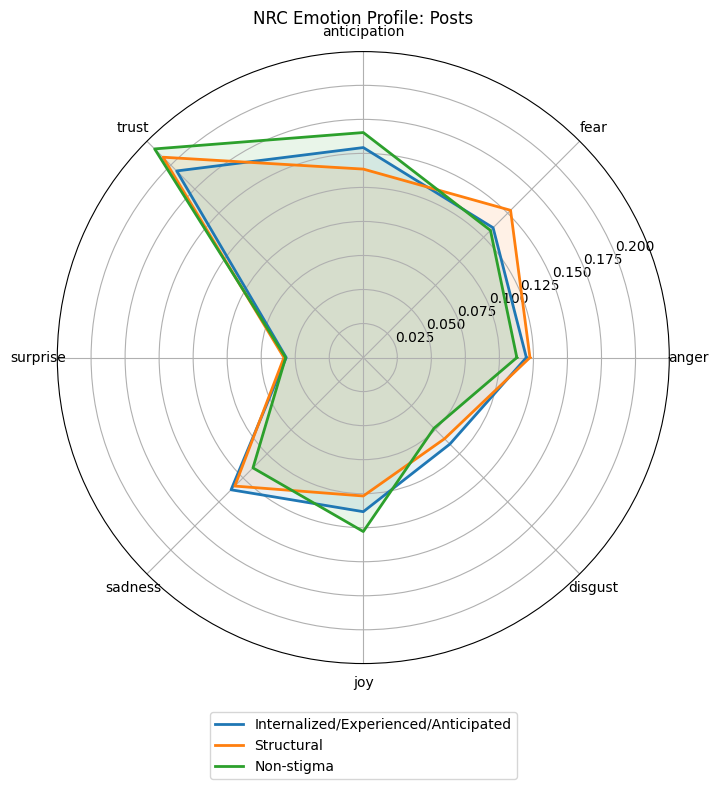

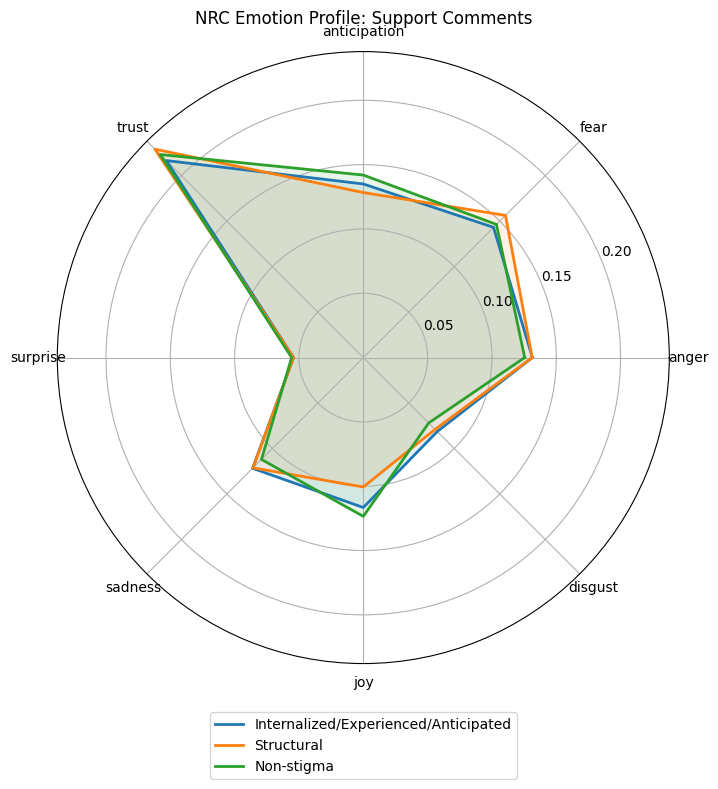

In [ ]:
def plot_radar_compare_3(df, col1, col2, col3, label1, label2, label3, title):
    categories = df["emotion"].tolist()

    vals1 = df[col1].tolist()
    vals2 = df[col2].tolist()
    vals3 = df[col3].tolist()

    categories = categories + [categories[0]]
    vals1 = vals1 + [vals1[0]]
    vals2 = vals2 + [vals2[0]]
    vals3 = vals3 + [vals3[0]]

    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=True)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.plot(angles, vals1, linewidth=2, label=label1)
    ax.fill(angles, vals1, alpha=0.10)

    ax.plot(angles, vals2, linewidth=2, label=label2)
    ax.fill(angles, vals2, alpha=0.10)

    ax.plot(angles, vals3, linewidth=2, label=label3)
    ax.fill(angles, vals3, alpha=0.10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(df["emotion"].tolist())
    ax.set_title(title, pad=20)

    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=1)

    plt.tight_layout()
    plt.show()

plot_radar_compare_3(
    post_emotion_df,
    col1="internalized_experienced_anticipated",
    col2="structural",
    col3="non_stigma",
    label1="Internalized/Experienced/Anticipated",
    label2="Structural",
    label3="Non-stigma",
    title="NRC Emotion Profile: Posts"
)

plot_radar_compare_3(
    support_emotion_df,
    col1="internalized_experienced_anticipated",
    col2="structural",
    col3="non_stigma",
    label1="Internalized/Experienced/Anticipated",
    label2="Structural",
    label3="Non-stigma",
    title="NRC Emotion Profile: Support Comments"
)

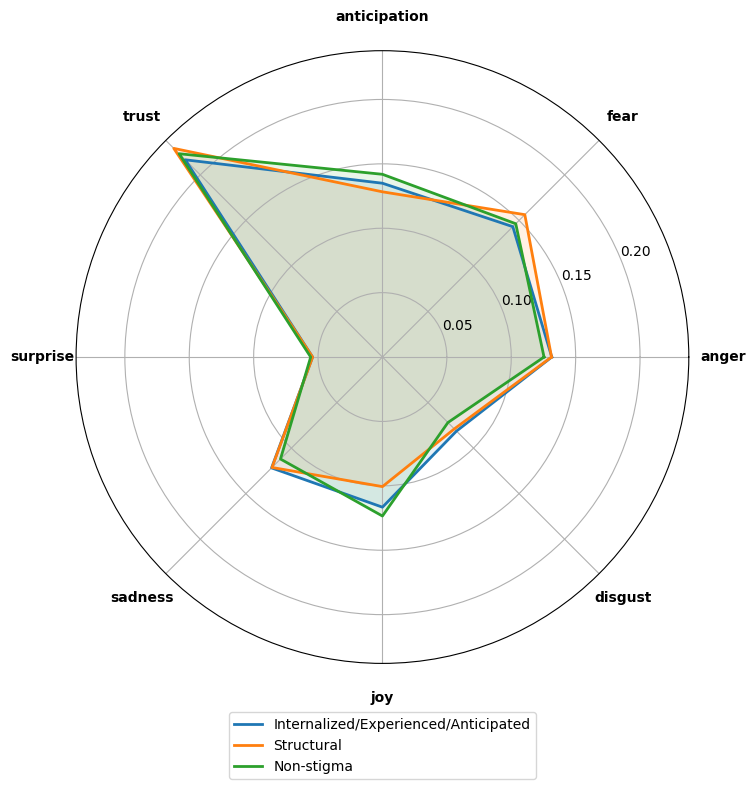

In [ ]:
def save_radar_compare_3(df, col1, col2, col3, label1, label2, label3, outpath):
    categories = df["emotion"].tolist()

    vals1 = df[col1].tolist()
    vals2 = df[col2].tolist()
    vals3 = df[col3].tolist()

    categories = categories + [categories[0]]
    vals1 = vals1 + [vals1[0]]
    vals2 = vals2 + [vals2[0]]
    vals3 = vals3 + [vals3[0]]

    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=True)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.plot(angles, vals1, linewidth=2, label=label1)
    ax.fill(angles, vals1, alpha=0.10)

    ax.plot(angles, vals2, linewidth=2, label=label2)
    ax.fill(angles, vals2, alpha=0.10)

    ax.plot(angles, vals3, linewidth=2, label=label3)
    ax.fill(angles, vals3, alpha=0.10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(df["emotion"].tolist(), fontweight="bold")
    ax.tick_params(axis='x', pad=14)

    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=1)

    plt.tight_layout()
    plt.savefig(outpath, bbox_inches="tight", dpi=300)
    plt.show()


# POSTS
save_radar_compare_3(
    support_emotion_df,
    col1="internalized_experienced_anticipated",
    col2="structural",
    col3="non_stigma",
    label1="Internalized/Experienced/Anticipated",
    label2="Structural",
    label3="Non-stigma",
    outpath="/content/nrc_support_radar.pdf"
)

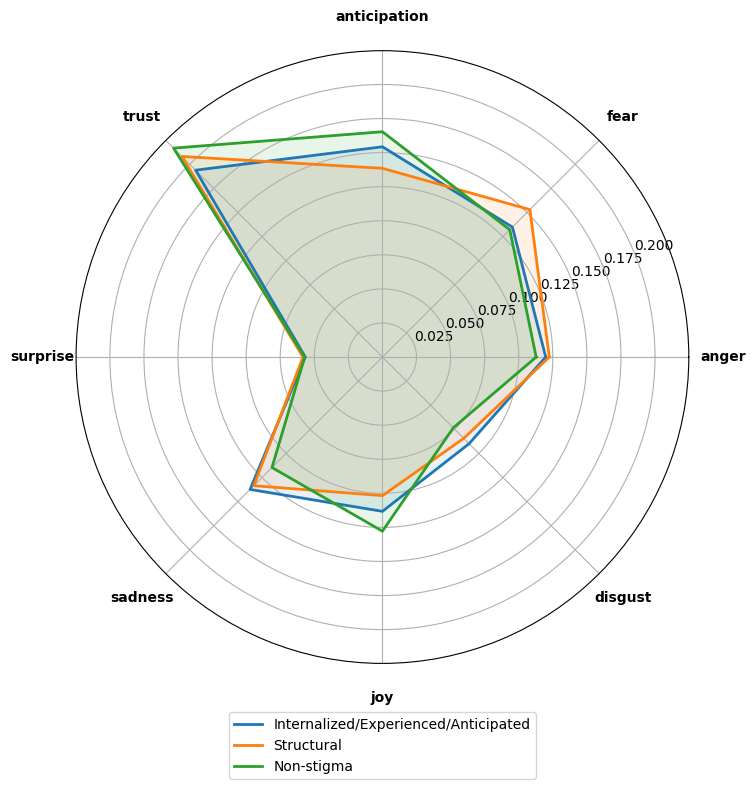

In [ ]:
save_radar_compare_3(
    post_emotion_df,
    col1="internalized_experienced_anticipated",
    col2="structural",
    col3="non_stigma",
    label1="Internalized/Experienced/Anticipated",
    label2="Structural",
    label3="Non-stigma",
    outpath="/content/nrc_posts_radar.pdf"
)

In [ ]:
def plot_radar_compare(df, col1, col2, label1, label2):
    categories = df["emotion"].tolist()
    vals1 = df[col1].tolist()
    vals2 = df[col2].tolist()

    categories = categories + [categories[0]]
    vals1 = vals1 + [vals1[0]]
    vals2 = vals2 + [vals2[0]]

    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=True)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.plot(angles, vals1, linewidth=2, label=label1)
    ax.fill(angles, vals1, alpha=0.15)

    ax.plot(angles, vals2, linewidth=2, label=label2)
    ax.fill(angles, vals2, alpha=0.15)

    ax.set_xticks(angles)
    ax.set_xticklabels(categories)
    # ax.set_title(title, pad=20, y=1.10)
    ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

    plt.tight_layout()
    plt.show()

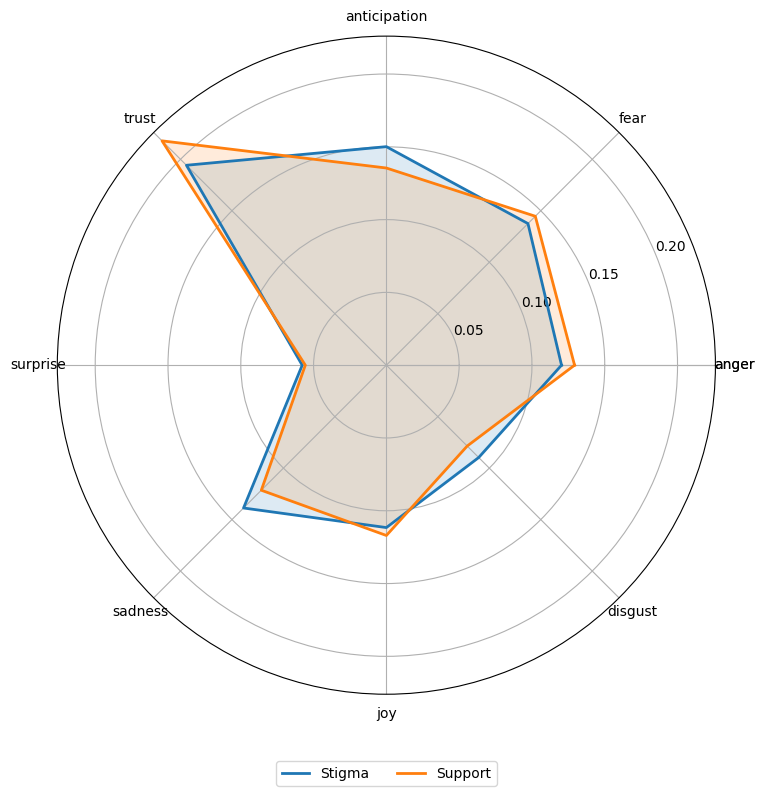

In [ ]:
plot_radar_compare(
    emotion_df,
    col1="stigma",
    col2="support",
    label1="Stigma",
    label2="Support",
    # title="NRC Emotion Radar Plot: Stigma vs Support"
)

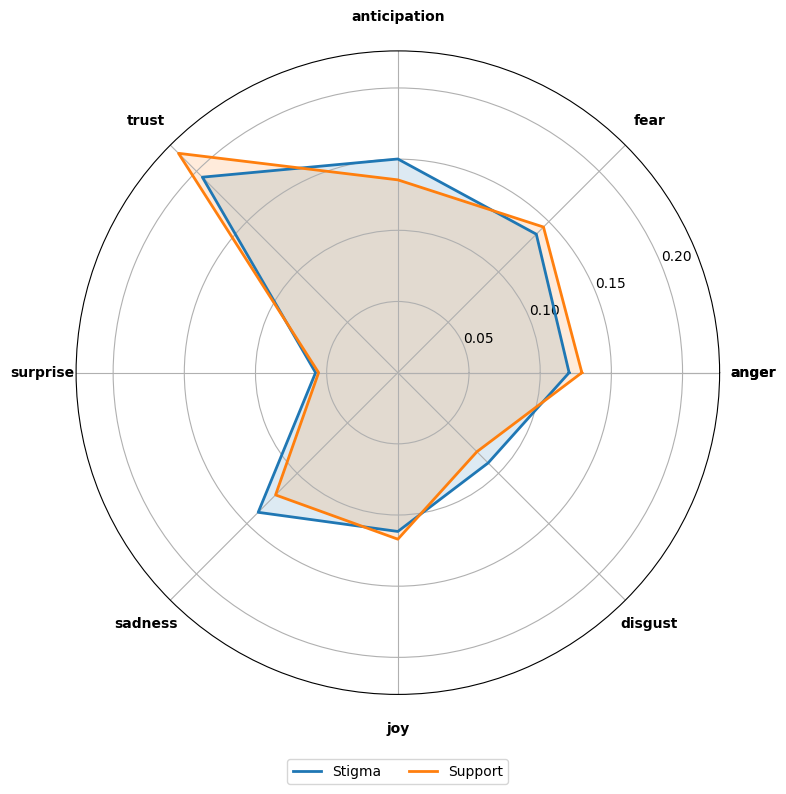

In [ ]:
def save_radar_compare(df, col1, col2, label1, label2, outpath):
    categories = df["emotion"].tolist()
    vals1 = df[col1].tolist()
    vals2 = df[col2].tolist()

    categories = categories + [categories[0]]
    vals1 = vals1 + [vals1[0]]
    vals2 = vals2 + [vals2[0]]

    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=True)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.plot(angles, vals1, linewidth=2, label=label1)
    ax.fill(angles, vals1, alpha=0.15)

    ax.plot(angles, vals2, linewidth=2, label=label2)
    ax.fill(angles, vals2, alpha=0.15)

    ax.set_xticks(angles)
    ax.set_xticklabels(categories, fontweight="bold")
    ax.tick_params(axis='x', pad=14)

    # ax.set_title(title, pad=20, y=1.10)
    ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

    plt.tight_layout()
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

save_radar_compare(
    emotion_df,
    col1="stigma",
    col2="support",
    label1="Stigma",
    label2="Support",
    outpath="/content/nrc_stigma_support_radar.pdf"
)

# Tag level preparation

In [ ]:
stigma_exploded = stigma_df[["post_id", "clean_text", "tag_list"]].explode("tag_list").copy()
support_exploded = support_df[["comment_id", "clean_text", "tag_list"]].explode("tag_list").copy()

stigma_exploded = stigma_exploded.dropna(subset=["tag_list"]).copy()
support_exploded = support_exploded.dropna(subset=["tag_list"]).copy()

print("Stigma exploded:", stigma_exploded.shape)
print("Support exploded:", support_exploded.shape)

Stigma exploded: (4732, 3)
Support exploded: (9311, 3)


In [ ]:
stigma_tag_counts = stigma_exploded["tag_list"].value_counts().reset_index()
stigma_tag_counts.columns = ["tag", "count"]

support_tag_counts = support_exploded["tag_list"].value_counts().reset_index()
support_tag_counts.columns = ["tag", "count"]

display(stigma_tag_counts.head(20))
display(support_tag_counts.head(20))

,tag,count
0,Internalized,1809
1,Anticipated,1325
2,Experienced,1273
3,Structural,325


,tag,count
0,Information Support,3095
1,Esteem Support,2383
2,Emotional Support,2197
3,Group Interaction,1114
4,Tangible Assistance,522


In [ ]:
def build_tag_emotion_profiles(exploded_df, text_id_col, top_n=10):
    top_tags = exploded_df["tag_list"].value_counts().head(top_n).index.tolist()
    rows = []

    for tag in top_tags:
        sub = exploded_df[exploded_df["tag_list"] == tag].copy()
        sub = sub.drop_duplicates(subset=[text_id_col])

        texts = sub["clean_text"].tolist()
        emo = compute_nrc_emotions(texts)

        row = {"tag": tag, "n_texts": len(texts)}
        for e in EMOTIONS:
            row[e] = emo.get(e, 0)
        rows.append(row)

    return pd.DataFrame(rows)

stigma_tag_emotions = build_tag_emotion_profiles(stigma_exploded, text_id_col="post_id", top_n=10)
support_tag_emotions = build_tag_emotion_profiles(support_exploded, text_id_col="comment_id", top_n=10)

display(stigma_tag_emotions)
display(support_tag_emotions)

,tag,n_texts,anger,fear,anticipation,trust,surprise,sadness,joy,disgust
0,Internalized,1809,0.121071,0.136955,0.150356,0.188225,0.058290,0.141573,0.111420,0.092111
1,Anticipated,1325,0.120072,0.140282,0.147217,0.196723,0.057813,0.139881,0.108825,0.089186
2,Experienced,1273,0.120406,0.137415,0.147045,0.198317,0.058239,0.137221,0.112746,0.088611
3,Structural,325,0.121600,0.152117,0.138048,0.205755,0.059419,0.135243,0.102346,0.085473


,tag,n_texts,anger,fear,anticipation,trust,surprise,sadness,joy,disgust
0,Information Support,3095,0.130186,0.148485,0.133396,0.222235,0.054958,0.121164,0.113186,0.076390
1,Esteem Support,2383,0.134766,0.145262,0.131993,0.211246,0.053529,0.126183,0.115951,0.081070
2,Emotional Support,2197,0.129452,0.140400,0.135546,0.214037,0.057001,0.122118,0.121822,0.079624
3,Group Interaction,1114,0.120585,0.138061,0.146592,0.209674,0.058932,0.122752,0.124274,0.079129
4,Tangible Assistance,522,0.121335,0.141838,0.140155,0.231082,0.055963,0.114600,0.121632,0.073395


In [ ]:
print("Stigma tag emotion profiles")
display(stigma_tag_emotions.set_index("tag").round(3))

print("Support tag emotion profiles")
display(support_tag_emotions.set_index("tag").round(3))

Stigma tag emotion profiles


,n_texts,anger,fear,anticipation,trust,surprise,sadness,joy,disgust
tag,,,,,,,,,
Internalized,1809,0.121,0.137,0.150,0.188,0.058,0.142,0.111,0.092
Anticipated,1325,0.120,0.140,0.147,0.197,0.058,0.140,0.109,0.089
Experienced,1273,0.120,0.137,0.147,0.198,0.058,0.137,0.113,0.089
Structural,325,0.122,0.152,0.138,0.206,0.059,0.135,0.102,0.085


Support tag emotion profiles


,n_texts,anger,fear,anticipation,trust,surprise,sadness,joy,disgust
tag,,,,,,,,,
Information Support,3095,0.130,0.148,0.133,0.222,0.055,0.121,0.113,0.076
Esteem Support,2383,0.135,0.145,0.132,0.211,0.054,0.126,0.116,0.081
Emotional Support,2197,0.129,0.140,0.136,0.214,0.057,0.122,0.122,0.080
Group Interaction,1114,0.121,0.138,0.147,0.210,0.059,0.123,0.124,0.079
Tangible Assistance,522,0.121,0.142,0.140,0.231,0.056,0.115,0.122,0.073


In [ ]:
def plot_tag_emotion_bars(tag_emotion_df, title):
    plot_df = tag_emotion_df.set_index("tag")[EMOTIONS]

    plot_df.plot(kind="bar", figsize=(12, 6))
    plt.title(title)
    plt.ylabel("Normalized Emotion Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

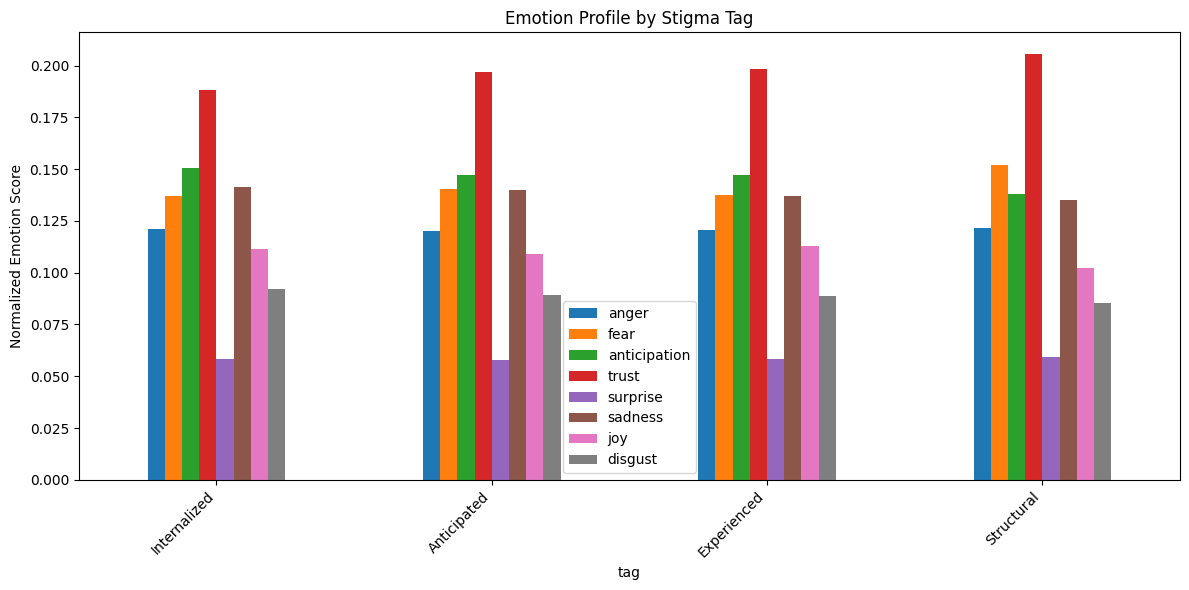

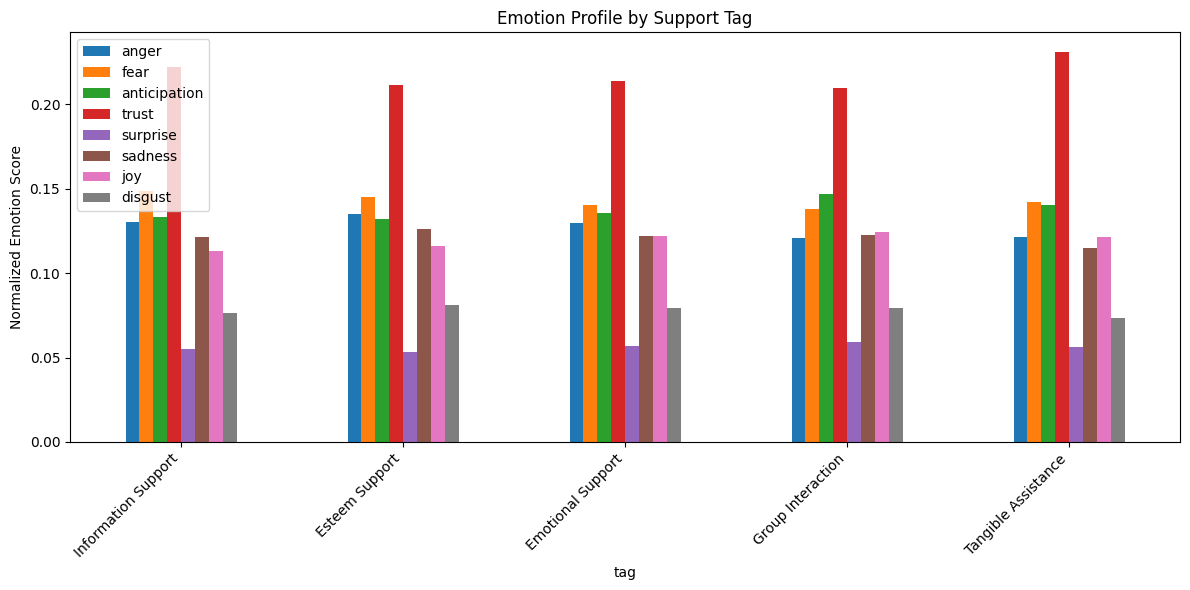

In [ ]:
plot_tag_emotion_bars(stigma_tag_emotions, "Emotion Profile by Stigma Tag")
plot_tag_emotion_bars(support_tag_emotions, "Emotion Profile by Support Tag")

In [ ]:
def radar_for_two_tags(tag_emotion_df, tag1, tag2, title):
    row1 = tag_emotion_df[tag_emotion_df["tag"] == tag1]
    row2 = tag_emotion_df[tag_emotion_df["tag"] == tag2]

    if len(row1) == 0 or len(row2) == 0:
        print("One or both tags not found.")
        return

    compare_df = pd.DataFrame({
        "emotion": EMOTIONS,
        tag1: [row1.iloc[0][e] for e in EMOTIONS],
        tag2: [row2.iloc[0][e] for e in EMOTIONS]
    })

    plot_radar_compare(
        compare_df,
        col1=tag1,
        col2=tag2,
        label1=tag1,
        label2=tag2,
        title=title
    )

Available stigma tags:
['Internalized', 'Anticipated', 'Experienced', 'Structural']

Available support tags:
['Information Support', 'Esteem Support', 'Emotional Support', 'Group Interaction', 'Tangible Assistance']


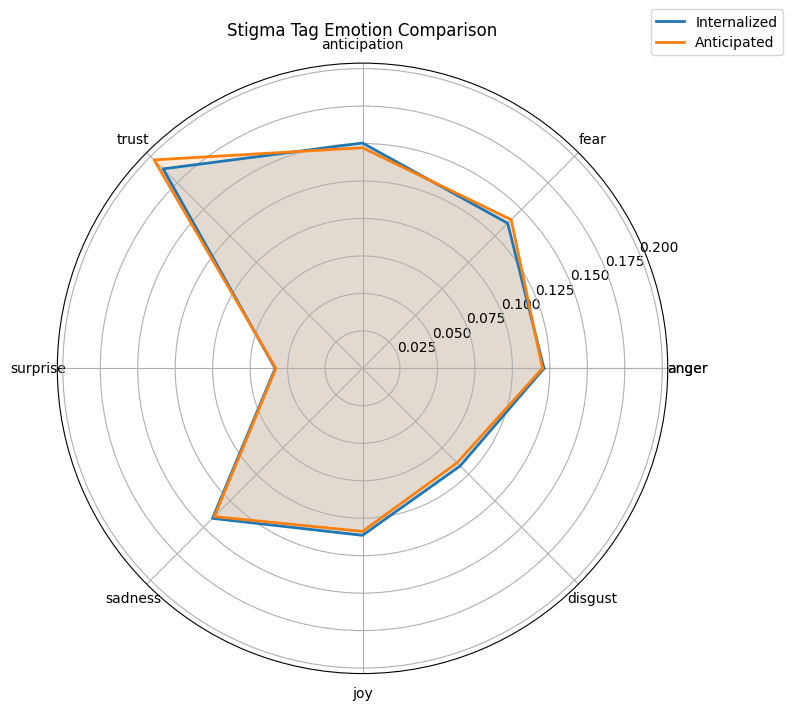

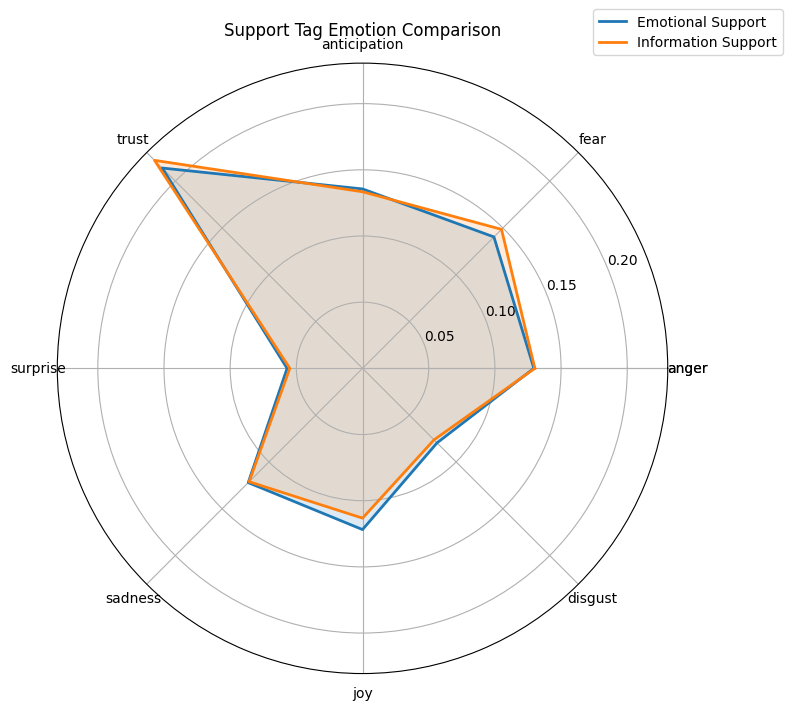

In [ ]:
print("Available stigma tags:")
print(stigma_tag_emotions["tag"].tolist())

print("\nAvailable support tags:")
print(support_tag_emotions["tag"].tolist())

# Example:
radar_for_two_tags(stigma_tag_emotions, "Internalized", "Anticipated", "Stigma Tag Emotion Comparison")
radar_for_two_tags(support_tag_emotions, "Emotional Support", "Information Support", "Support Tag Emotion Comparison")

In [ ]:
def dominant_emotion(text):
    raw = get_nrc_emotion_counts([text])
    if sum(raw.values()) == 0:
        return None
    return max(raw, key=raw.get)

In [ ]:
stigma_df["dominant_emotion"] = stigma_df["clean_text"].apply(dominant_emotion)
support_df["dominant_emotion"] = support_df["clean_text"].apply(dominant_emotion)

display(stigma_df[["post_id", "dominant_emotion"]].head())
display(support_df[["post_id", "comment_id", "dominant_emotion"]].head())

,post_id,dominant_emotion
0,om798f,trust
1,ol3l81,trust
2,ojmgbg,trust
4,ojkjeq,trust
8,o9i5c6,anger


,post_id,comment_id,dominant_emotion
0,om798f,h5j5kk8,trust
1,ol3l81,h5bz1on,anger
2,ojmgbg,h52l5q5,trust
3,ojmgbg,h5314q6,trust
4,ojkjeq,h52fift,sadness


In [ ]:
flow_df = support_df.merge(
    stigma_df[["post_id", "dominant_emotion"]],
    on="post_id",
    how="inner",
    suffixes=("_support", "_stigma")
)

flow_df = flow_df.dropna(subset=["dominant_emotion_support", "dominant_emotion_stigma"]).copy()

flow_table = pd.crosstab(
    flow_df["dominant_emotion_stigma"],
    flow_df["dominant_emotion_support"]
)

display(flow_table)

dominant_emotion_support,anger,anticipation,disgust,fear,joy,sadness,surprise,trust
dominant_emotion_stigma,,,,,,,,
anger,102,61,3,53,8,22,4,117
anticipation,153,150,6,86,7,35,1,242
disgust,23,9,3,7,0,0,0,18
fear,120,82,2,83,6,29,2,198
joy,4,6,0,7,2,4,1,12
sadness,72,59,7,64,9,32,2,139
surprise,0,1,1,2,0,0,0,3
trust,373,248,21,201,37,106,8,675


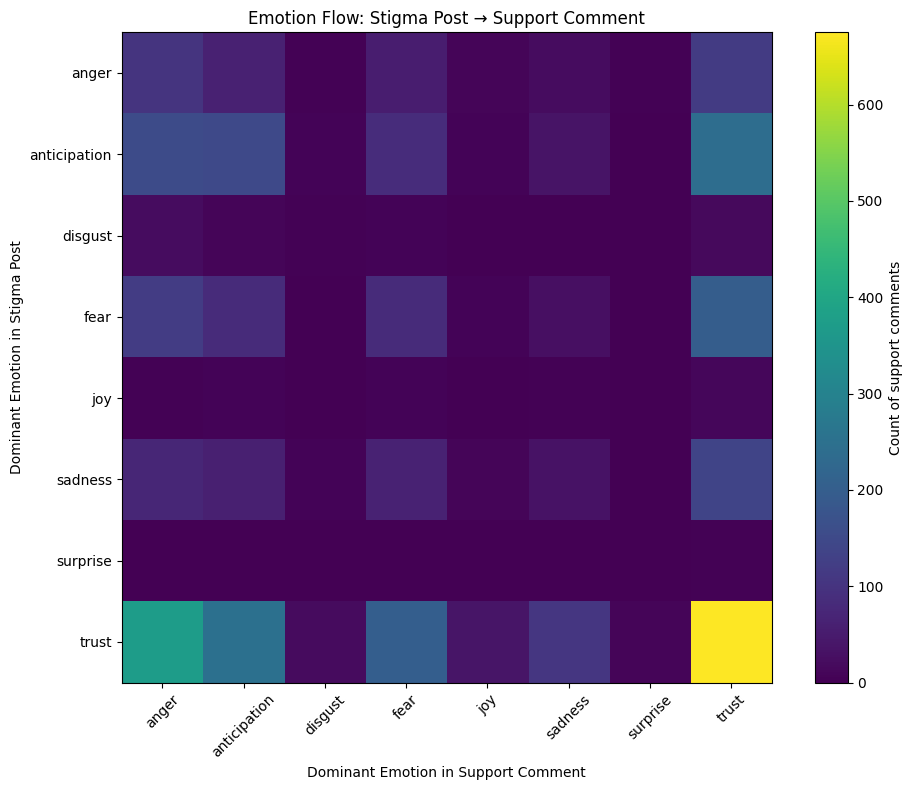

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(flow_table, interpolation="nearest")
plt.colorbar(label="Count of support comments")

plt.xticks(range(len(flow_table.columns)), flow_table.columns, rotation=45)
plt.yticks(range(len(flow_table.index)), flow_table.index)

plt.xlabel("Dominant Emotion in Support Comment")
plt.ylabel("Dominant Emotion in Stigma Post")
plt.title("Emotion Flow: Stigma Post → Support Comment")

plt.tight_layout()
plt.show()

dominant_emotion_support,anger,anticipation,disgust,fear,joy,sadness,surprise,trust
dominant_emotion_stigma,,,,,,,,
anger,0.276,0.165,0.008,0.143,0.022,0.059,0.011,0.316
anticipation,0.225,0.221,0.009,0.126,0.010,0.051,0.001,0.356
disgust,0.383,0.150,0.050,0.117,0.000,0.000,0.000,0.300
fear,0.230,0.157,0.004,0.159,0.011,0.056,0.004,0.379
joy,0.111,0.167,0.000,0.194,0.056,0.111,0.028,0.333
sadness,0.188,0.154,0.018,0.167,0.023,0.083,0.005,0.362
surprise,0.000,0.143,0.143,0.286,0.000,0.000,0.000,0.429
trust,0.223,0.149,0.013,0.120,0.022,0.064,0.005,0.404


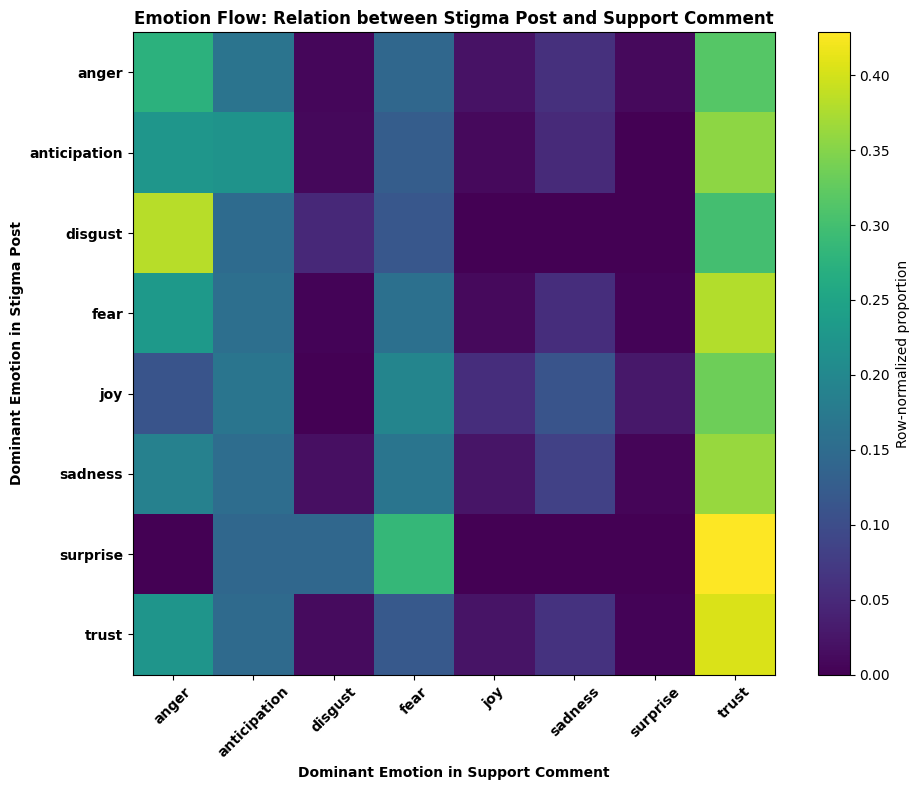

In [ ]:
flow_table_norm = flow_table.div(flow_table.sum(axis=1), axis=0).fillna(0)

display(flow_table_norm.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(flow_table_norm, interpolation="nearest")
plt.colorbar(label="Row-normalized proportion", )

plt.xticks(range(len(flow_table_norm.columns)), flow_table_norm.columns, rotation=45, fontweight='bold')
plt.yticks(range(len(flow_table_norm.index)), flow_table_norm.index, fontweight='bold')

plt.xlabel("Dominant Emotion in Support Comment", fontweight='bold')
plt.ylabel("Dominant Emotion in Stigma Post", fontweight='bold')
plt.title("Emotion Flow: Relation between Stigma Post and Support Comment", fontweight='bold')

plt.tight_layout()
plt.savefig("/content/emotion_flow_heatmap.pdf", bbox_inches="tight")

plt.show()

In [ ]:
emotion_df.to_csv("/content/nrc_dataset_level_emotions.csv", index=False)
stigma_tag_emotions.to_csv("/content/nrc_stigma_tag_emotions.csv", index=False)
support_tag_emotions.to_csv("/content/nrc_support_tag_emotions.csv", index=False)
flow_table.to_csv("/content/nrc_emotion_flow_counts.csv")
flow_table_norm.to_csv("/content/nrc_emotion_flow_normalized.csv")

if "stigma_concept_emotions" in globals():
    stigma_concept_emotions.to_csv("/content/nrc_stigma_concept_emotions.csv", index=False)

if "support_concept_emotions" in globals():
    support_concept_emotions.to_csv("/content/nrc_support_concept_emotions.csv", index=False)

print("Saved NRC analysis outputs to /content/")

Saved NRC analysis outputs to /content/
